# BTC HMM Regime Analysis

**Author:** Sergej Schweizer  
**Date:** April 15, 2026

## Overview

This notebook analyzes latent BTC market regimes with Hidden Markov Models using the enriched Deribit dataset created in the feature-engineering step.

## What This Notebook Does

- loads the enriched BTC market dataset
- defines candidate feature blocks for HMM regime modeling
- runs automatic HMM feature-subset selection
- fits a selected HMM configuration
- evaluates inferred regimes through tables, plots, transition structure, and posterior confidence metrics


## Table of Contents

- [What The HMM Does](#What-The-HMM-Does)
- [How Selection Works](#How-Selection-Works)
- [Statistic 1-2: Dataset And Candidate Features](#Statistic-1-2-Dataset-And-Candidate-Features)
- [Statistic 3: Selection Summary Of Top HMM Configurations](#Statistic-3-Selection-Summary-Of-Top-HMM-Configurations)
- [Statistics 4-7: Chosen HMM Configuration](#Statistics-4-7-Chosen-HMM-Configuration)
- [Statistic 8: State Profile By Inferred Regime](#Statistic-8-State-Profile-By-Inferred-Regime)
- [Figure 1: Recent HMM Regime Chart](#Figure-1-Recent-HMM-Regime-Chart)
- [Figure 2: Full-History HMM Regime Overlay](#Figure-2-Full-History-HMM-Regime-Overlay)
- [Figure 3 And Statistic 9: Regime Distribution](#Figure-3-And-Statistic-9-Regime-Distribution)
- [Statistics 10-11: Regime Duration Statistics](#Statistics-10-11-Regime-Duration-Statistics)
- [Statistic 12: Transition Matrix](#Statistic-12-Transition-Matrix)
- [Statistics 13-14: Posterior Confidence](#Statistics-13-14-Posterior-Confidence)


In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.hmm_utils import (
    add_hmm_features,
    assign_regimes,
    automatic_hmm_feature_selection,
    build_candidate_features,
    compute_run_lengths,
    fit_hmm_from_results_index,
    load_dataset,
    plot_full_regime_overlay,
    plot_recent_regimes,
    resolve_hmm_columns,
    summarize_state_profile,
    summarize_hmm_results,
)
import importlib


## What The HMM Does

Let $x_t \in \mathbb{R}^d$ be the standardized feature vector at time $t$ and let $z_t \in \{1, \ldots, K\}$ be the latent market regime. The notebook fits a Gaussian Hidden Markov Model with:

- state dynamics: $P(z_t = j \mid z_{t-1} = i) = A_{ij}$
- initial state probabilities: $P(z_1 = k) = \pi_k$
- Gaussian emissions: $x_t \mid z_t = k \sim \mathcal{N}(\mu_k, \Sigma_k)$

The current search uses `covariance_type="full"`, so each hidden state gets its own full covariance matrix $\Sigma_k$. After fitting, the model computes posterior state probabilities

$$\gamma_{t,k} = P(z_t = k \mid x_{1:T})$$

and derives:

- `hmm_state`: the most likely state label
- `hmm_prob_k`: posterior probability of state $k$
- `hmm_max_prob = \max_k \gamma_{t,k}`
- `hmm_entropy = -\sum_k \gamma_{t,k} \log(\gamma_{t,k} + \varepsilon)`

Lower entropy means the model is more certain about the regime assignment at that timestamp.

## How Selection Works

Each candidate feature subset is fit on the chronological training split only. For the inferred state sequence $\hat z_1, \ldots, \hat z_T$, the notebook tracks:

- average self-transition probability: $\text{avg\_self\_transition} = \frac{1}{K}\sum_{k=1}^K A_{kk}$
- state usage: $\text{state\_fraction}_k = \frac{1}{T}\sum_{t=1}^T \mathbf{1}[\hat z_t = k]$
- minimum state usage: $\text{min\_state\_fraction} = \min_k \text{state\_fraction}_k$
- train log-likelihood: $\text{train\_loglik} = \log p(x_{1:T} \mid \theta)$
- normalized fit term: $\text{loglik\_per\_obs\_per\_feature} = \frac{\text{train\_loglik}}{T d}$

A model is considered eligible only if it converged and

$$\text{min\_state\_fraction} \ge 0.05$$

For eligible models, the ranking score is

$$\text{selection\_score} = 3.0\,\text{avg\_self\_transition} + 1.5\,\text{min\_state\_fraction} - 0.25\,\text{median\_run\_length} - 2.5\,\text{avg\_entropy} + 0.05\,\text{loglik\_per\_obs\_per\_feature}$$

So the code favors persistent and reasonably balanced regimes with low posterior uncertainty, while using normalized likelihood only as a weak extra term. The negative median-run-length coefficient discourages extremely long uninterrupted state runs.

The summary table is then ordered by `selection_score` first, with `avg_self_transition`, `min_state_fraction`, `median_run_length`, `avg_entropy`, and `loglik_per_obs_per_feature` used as later tie-breakers.


In [63]:
DATA_PATH = Path("data/deribit_enriched_data.csv")
RESULTS_PATH = Path("data/hmm_feature_selection_summary.csv")
SELECTED_RESULT_INDEX = 0
PRICE_COL = "close_perp"
N_RECENT_POINTS = 300

FEATURE_BLOCKS = {
    "market_basics": ["close_perp", "volume_perp", "volume_spot"],
    "activity": ["log_volume_perp", "ma_24h_volume_perp", "z_24h_volume_perp"],
    "structure": ["volume_perp_to_spot", "perp_volume_share"],
    "volatility": ["std_72h_sq_return_close_perp", "std_24h_return_close_perp"],
    "price_dynamics": ["return_close_perp", "return_close_spot"],
    "stress": ["cost_x_volume_perp", "z_24h_cost_perp", "abs_cost_perp"],
    "funding": ["interest_8h", "interest_1h"],
}

SEARCH_CONFIG = {
    "subset_min_size": 2,
    "subset_max_size": 3,
    "n_states_list": [3],
    "min_state_fraction_threshold": 0.05,
    "top_k": 20,
}


In [7]:
df = load_dataset(DATA_PATH)
candidate_features, missing_features = build_candidate_features(df, FEATURE_BLOCKS)

print(f"Statistic 1. Loaded dataset with shape: {df.shape}")
print(f"Statistic 2. Using {len(candidate_features)} candidate features")
display(pd.Series(candidate_features, name="candidate_feature"))

if missing_features:
    print("Skipped missing features by block:")
    display(pd.Series({block: ", ".join(features) for block, features in missing_features.items()}))

df.head(3)


Loaded dataset with shape: (20521, 81)
Using 17 candidate features


0                       close_perp
1                      volume_perp
2                      volume_spot
3                  log_volume_perp
4               ma_24h_volume_perp
5                z_24h_volume_perp
6              volume_perp_to_spot
7                perp_volume_share
8     std_72h_sq_return_close_perp
9        std_24h_return_close_perp
10               return_close_perp
11               return_close_spot
12              cost_x_volume_perp
13                 z_24h_cost_perp
14                   abs_cost_perp
15                     interest_8h
16                     interest_1h
Name: candidate_feature, dtype: str

,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,...,std_72h_sq_return_close_perp,std_72h_sq_return_index_price,ATR_24h_spot,ATR_72h_spot,ATR_24h_spot_norm,ATR_72h_spot_norm,ATR_24h_perp,ATR_72h_perp,ATR_24h_perp_norm,ATR_72h_perp_norm
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
results = automatic_hmm_feature_selection(
    df=df,
    candidate_features=candidate_features,
    **SEARCH_CONFIG,
)

summary = summarize_hmm_results(results, top_n=10, stringify_features=True)
summary.to_csv(RESULTS_PATH, index=False)
print('Statistic 3. Selection summary of top HMM configurations')
display(summary)


HMM feature search: 100%|██████████| 1925/1925 [2:06:20<00:00,  3.94s/fit, best=2.284 | close_perp,volume_perp,abs_cost_perp | S=0.90 | R=3.0 | E=0.032]


,feature_cols,n_states,n_features,n_obs_used,eligible,selection_score,train_loglik,loglik_per_obs,loglik_per_obs_per_feature,min_state_fraction,avg_self_transition,median_run_length,avg_entropy,aic,bic
0,"close_perp, volume_perp, abs_cost_perp",3,3,12312,True,2.284322,2377.797260,0.193128,0.064376,0.264051,0.904622,3.0,0.031536,-4685.594520,-4425.952981
1,"close_perp, volume_perp, abs_cost_perp, intere...",3,4,12312,True,2.109033,-12877.814476,-1.045956,-0.261489,0.289474,0.918380,4.0,0.026897,25855.628953,26226.545437
2,"close_perp, volume_perp, std_24h_return_close_...",3,4,12288,True,2.107301,-13553.397537,-1.102978,-0.275745,0.228190,0.878426,3.0,0.042590,27206.795073,27577.613996
3,"close_perp, volume_perp, log_volume_perp, std_...",3,4,12288,True,2.045207,-36422.410135,-2.964063,-0.741016,0.262288,0.851466,3.0,0.046229,72944.820269,73315.639192
4,"close_perp, ma_24h_volume_perp, z_24h_volume_p...",3,4,12289,True,2.038027,-38377.307759,-3.122899,-0.780725,0.247376,0.862318,3.0,0.052381,76854.615519,77225.438510
5,"close_perp, volume_perp, z_24h_volume_perp, st...",3,4,12240,True,2.030295,-42050.149889,-3.435470,-0.858867,0.253513,0.930612,4.0,0.039547,84200.299778,84570.923006
6,"close_perp, volume_spot, z_24h_volume_perp, pe...",3,4,12289,True,2.026903,-41155.491871,-3.348970,-0.837242,0.226219,0.796988,2.0,0.064610,82410.983742,82781.806734
7,"ma_24h_volume_perp, std_24h_return_close_perp,...",3,3,12288,True,2.022888,-24615.488468,-2.003214,-0.667738,0.253906,0.867646,3.0,0.071009,49300.976937,49560.550183
8,"log_volume_perp, ma_24h_volume_perp, std_24h_r...",3,4,12288,True,2.016552,-39614.660185,-3.223849,-0.805962,0.253092,0.868420,3.0,0.071219,79329.320370,79700.139293
9,"ma_24h_volume_perp, std_24h_return_close_perp,...",3,4,12288,True,2.007172,-41126.303728,-3.346867,-0.836717,0.252441,0.866039,3.0,0.071108,82352.607456,82723.426379


**Statistic 3 explanation.** This table shows the best HMM configurations tested. In this project the main ranking formula is `3.0 * avg_self_transition + 1.5 * min_state_fraction - 0.25 * median_run_length - 2.5 * avg_entropy + 0.05 * loglik_per_obs_per_feature`, with a hard eligibility rule that rejects any non-converged fit or any fit with `min_state_fraction < 0.05`.

In [65]:
hmm, scaler, best_features, best_n_states = fit_hmm_from_results_index(
    df=df,
    results_df=results,
    selected_idx=SELECTED_RESULT_INDEX,
)

df_hmm = add_hmm_features(df, hmm, scaler, best_features)
df_full = pd.concat([df, df_hmm], axis=1)
state_col, prob_cols = resolve_hmm_columns(df_full)

print(f"Statistic 4. Selected row: {SELECTED_RESULT_INDEX}")
print(f"Statistic 5. Best features: {best_features}")
print(f"Statistic 6. Number of states: {best_n_states}")

selected_result = results.loc[[SELECTED_RESULT_INDEX], [
    "feature_cols",
    "n_states",
    "selection_score",
    "avg_self_transition",
    "median_run_length",
    "avg_entropy",
]]
print('Statistic 7. Chosen HMM configuration metrics')
display(selected_result)


Selected row: 0
Best features: ['close_perp', 'volume_perp', 'abs_cost_perp']
Number of states: 3


,feature_cols,n_states,selection_score,avg_self_transition,median_run_length,avg_entropy
0,"[close_perp, volume_perp, abs_cost_perp]",3,2.284322,0.904622,3.0,0.031536


**Statistic 7 explanation.** This is the model variant that is actually carried forward in the workflow. These metrics help assess how "sticky" the states are, how long a regime typically lasts, and how clearly the model separates one state from another.

In [66]:
import src.hmm_utils as hmm_utils
import importlib

importlib.reload(hmm_utils)

<module 'src.hmm_utils' from 'c:\\code\\FE\\src\\hmm_utils.py'>

In [67]:
state_profile = summarize_state_profile(
    df_full,
    state_col=state_col,
    feature_cols=best_features
)

regime_labels, regime_colors = hmm_utils.assign_regimes(state_profile)

print('Statistic 8. State profile by inferred regime')
display(state_profile)
print(regime_labels)
print(regime_colors)

,close_perp,abs_return_close_perp,volume_perp,abs_cost_perp
hmm_state,,,,
0.0,70057.626229,0.006075,865.673928,6.496480e+07
1.0,65097.861430,0.002880,232.866168,1.517882e+07
2.0,99863.360009,0.002540,230.937906,2.292928e+07


{2.0: 'Low Activity', 0.0: 'Stress', 1.0: 'Active / Trend'}
{2.0: 'lightgrey', 0.0: 'lightcoral', 1.0: 'lightgreen'}


**Statistic 8 explanation.** This overview translates the latent HMM states into observable market behavior. High average activity, elevated absolute returns, or unusual cost/funding patterns help interpret the numerical states as calm, active, or stressed market phases.

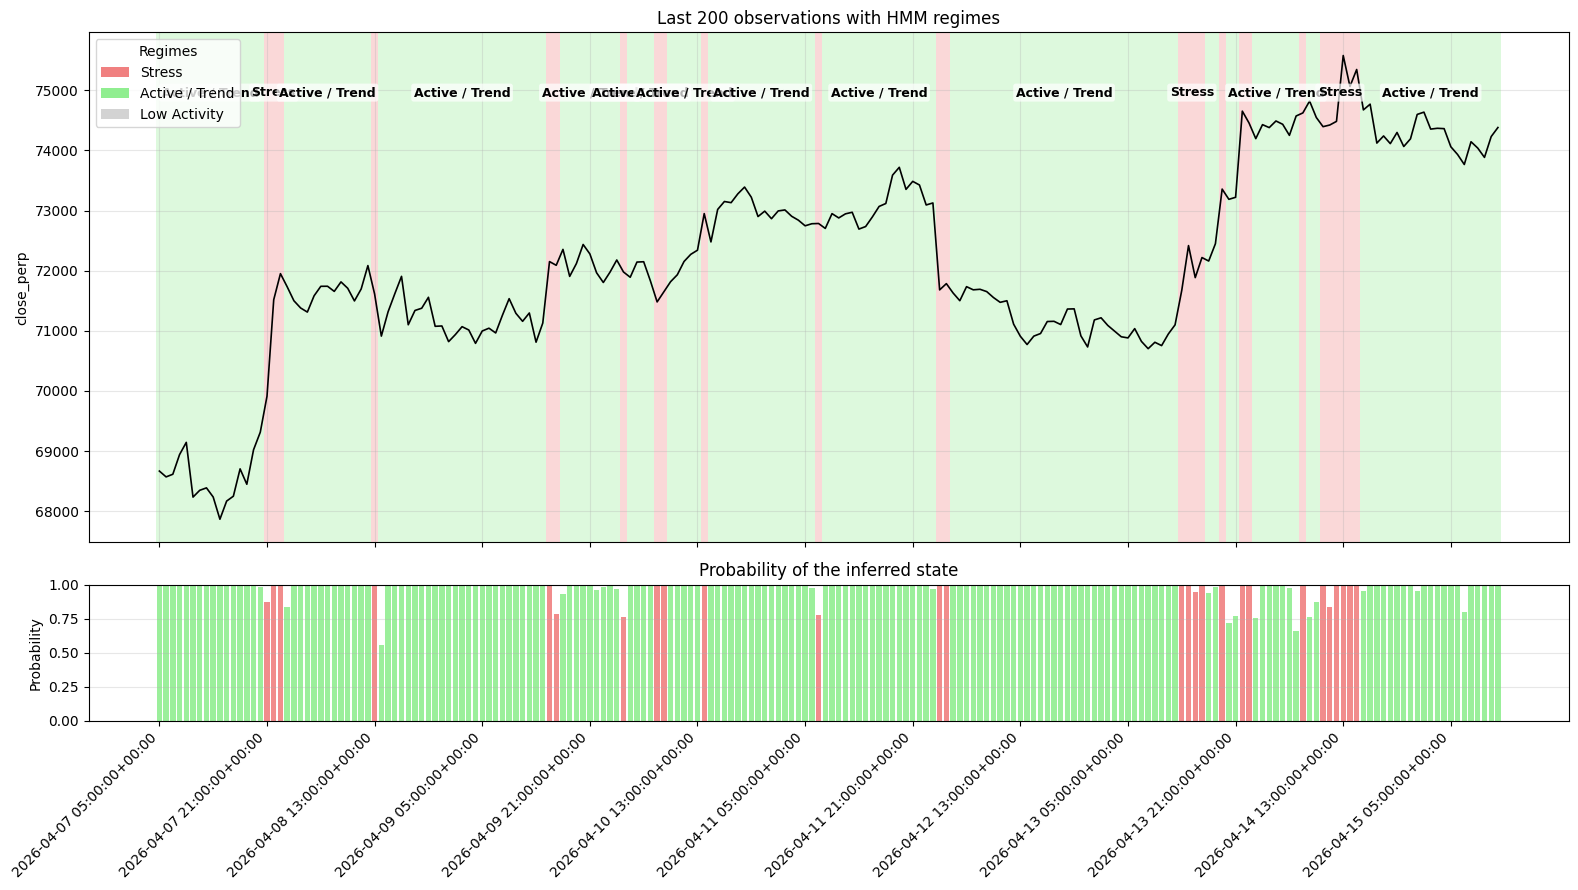

In [68]:
print('Figure 1. Recent HMM regime chart')
plot_recent_regimes(
    df=df_full,
    price_col=PRICE_COL,
    state_col=state_col,
    prob_cols=prob_cols,
    regime_labels=regime_labels,
    regime_colors=regime_colors,
    n_points=200,
)


**Figure 1 insight.** The upper panel shows the most recent price action together with the regime phases identified by the HMM. The lower probabilities reveal when the classification is especially confident and when transition periods or fuzzy boundaries between states appear.

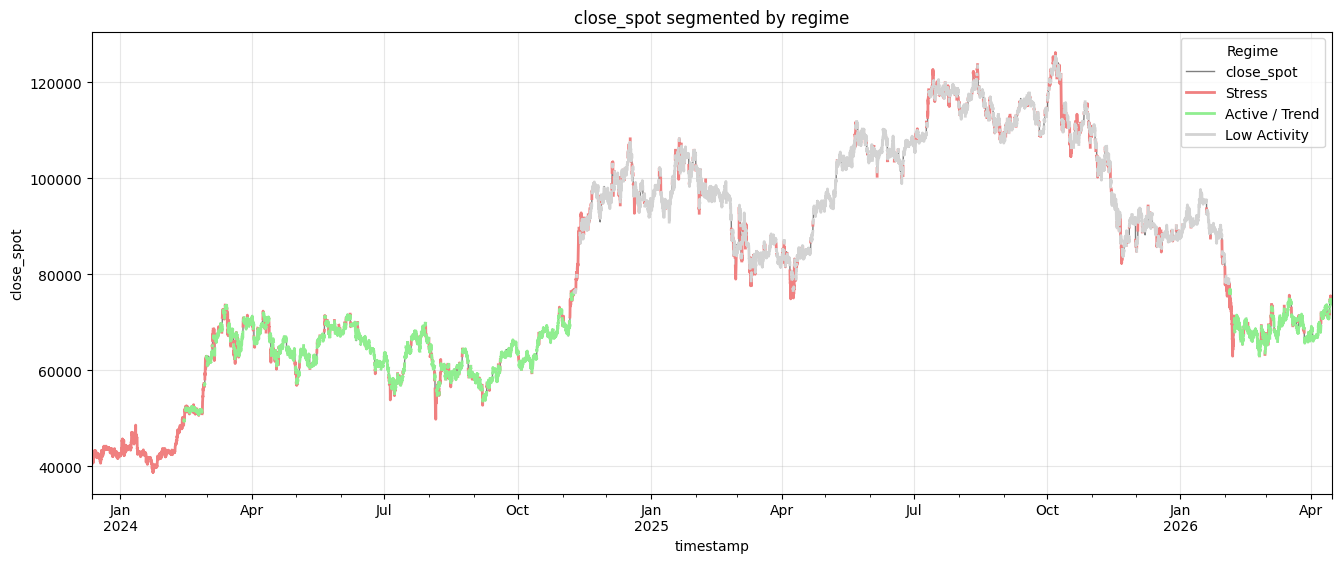

In [69]:
print('Figure 2. Full-history HMM regime overlay')
plot_full_regime_overlay(
    df=df_full,
    price_col="close_spot",
    state_col=state_col,
    regime_labels=regime_labels,
    regime_colors=regime_colors,
)


**Figure 2 insight.** This plot shows which market segments each regime dominates across the full history. If certain colors repeatedly appear during rallies, corrections, or quiet sideways periods, that suggests economically meaningful regimes rather than random segmentation.

,state_fraction
hmm_state,
0,0.218118
1,0.331270
2,0.450612


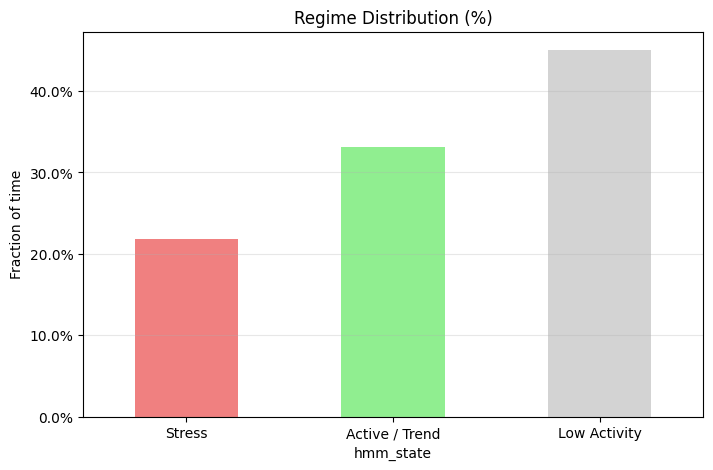

In [70]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# -------------------------
# Compute fractions
# -------------------------
state_counts = (
    df_full[state_col]
    .dropna()
    .astype(int)
    .value_counts(normalize=True)
    .sort_index()
    .rename("state_fraction")
)

print('Statistic 9. Regime occupancy fractions')
display(state_counts.to_frame())

# -------------------------
# Prepare labels + colors
# -------------------------
labels = [regime_labels.get(state, f"State {state}") for state in state_counts.index]
colors = [regime_colors.get(state, "grey") for state in state_counts.index]

# -------------------------
# Plot
# -------------------------
ax = state_counts.plot(
    kind="bar",
    color=colors,
    title="Figure 3. Regime Distribution (%)",
    figsize=(8, 5)
)

ax.set_xticklabels(labels, rotation=0)

# format y-axis as percentage
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylabel("Fraction of time")
ax.grid(axis="y", alpha=0.3)

plt.show()

**Figure 3 / Statistic 9 explanation.** This output shows how much of the full dataset each regime occupies. A useful HMM should neither be dominated by a single state nor produce completely uniform regimes that barely differ in substance.

In [71]:
run_lengths = compute_run_lengths(df_full[state_col])
print(f"Statistic 10. Mean run length: {run_lengths.mean():.2f}")
print(f"Statistic 11. Median run length: {run_lengths.median():.2f}")


Mean run length: 10.25
Median run length: 3.00


**Statistics 10-11 explanation.** The mean and median run lengths describe how long a state typically persists. Larger values point to more persistent, structurally stable market phases, while smaller values suggest more frequent regime changes and a noisier market environment.

In [72]:
trans_mat = pd.DataFrame(
    hmm.transmat_,
    index=[f"from_{state}" for state in range(best_n_states)],
    columns=[f"to_{state}" for state in range(best_n_states)],
)
print('Statistic 12. Transition matrix')
display(trans_mat)


,to_0,to_1,to_2
from_0,0.832414,1.101820e-01,5.740353e-02
from_1,0.068244,9.317557e-01,9.709262e-96
from_2,0.050303,8.844708e-97,9.496970e-01


**Statistic 12 explanation.** The diagonal measures regime persistence, while the off-diagonal entries show the most likely transitions. Distinct transition paths can indicate recurring market sequences, for example from calm to active and then to stressed conditions.

In [73]:
print(f"Statistic 13. Avg max prob: {df_full['hmm_max_prob'].mean():.4f}")
print(f"Statistic 14. Avg entropy: {df_full['hmm_entropy'].mean():.4f}")


Avg max prob: 0.9888
Avg entropy: 0.0284


**Statistics 13-14 explanation.** A high average maximum probability means the model assigns observations to a state fairly decisively. Low entropy supports that interpretation because it points to clearly separated regimes, while higher entropy suggests overlapping or less sharply defined states.